# Employee Turnover Prediction

## Project overview

This project analyzes employee data from the fictional Salifort Motors business scenario to identify factors associated with employee turnover and build a model that predicts whether an employee is likely to leave the company.

The project was completed as the capstone for the **Google Advanced Data Analytics Professional Certificate on Coursera**. The dataset, fictional business scenario, and original notebook framework were provided as part of the course. The data cleaning decisions, exploratory analysis, visualizations, model development and tuning, model selection, evaluation, interpretation, and recommendations presented in this notebook reflect my work.

### Reproducibility note
The original dataset was supplied within the Coursera course environment and is no longer available to me, so it is not included in this repository. Executed notebook outputs have been retained so the analysis and results can still be reviewed.


## Business problem

Salifort Motors' HR department wants to improve employee satisfaction and retention. The objective of this analysis is to identify patterns associated with turnover and build a predictive model that can help HR identify employees who may be at elevated risk of leaving.

### Stakeholders and analytical objective
The primary stakeholders are company leadership and the HR department. The modeling task is a **binary classification problem**: predict whether an employee will leave (`left = 1`) or remain with the company (`left = 0`).


## Dataset

The course-provided dataset contains approximately 15,000 employee records and variables describing satisfaction, performance evaluations, project workload, monthly hours, tenure, workplace accidents, promotions, department, salary level, and whether the employee left the company.

Most variables are numeric; `department` and `salary` are categorical. The target variable is `left`.


### Ethical considerations

The dataset does not contain direct personal identifiers. Nevertheless, employee-retention models should be used as decision-support tools rather than as a basis for adverse employment decisions. Predictions can be imperfect, and any intervention based on model output should respect employee privacy and be designed to improve working conditions rather than penalize individuals.


In [2]:
# Import packages
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, \
confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve, auc, RocCurveDisplay, PrecisionRecallDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import plot_importance, XGBClassifier

import pickle

pd.set_option('display.max_columns', None)

In [3]:
# Load dataset into a dataframe
df0 = pd.read_csv("HR_capstone_dataset.csv")

# Display first few rows of the dataframe
df0.head(10)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
5,0.41,0.50,2,153,3,0,1,0,sales,low
6,0.10,0.77,6,247,4,0,1,0,sales,low
7,0.92,0.85,5,259,5,0,1,0,sales,low
8,0.89,1.00,5,224,5,0,1,0,sales,low
9,0.42,0.53,2,142,3,0,1,0,sales,low


In [4]:
# Create a copy of the dataset
df = df0.copy()

In [5]:
# Gather basic information about the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [6]:
# Gather descriptive statistics about the data
### YOUR CODE HERE ###
df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [7]:
# Display all column names
print(df.columns)

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')


In [8]:
# Rename columns as needed
df = df.rename(columns={"time_spend_company":"time_spent_company", "average_montly_hours":"average_monthly_hours", "Work_accident":"work_accident", "Department":"department"})

# Display all column names after the update
print(df.columns)

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_monthly_hours', 'time_spent_company', 'work_accident', 'left',
       'promotion_last_5years', 'department', 'salary'],
      dtype='object')


In [9]:
# Check for missing values
df.isna().any(axis=1).sum()

0

In [10]:
# Check for duplicates
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
14994     True
14995     True
14996     True
14997     True
14998     True
Length: 14999, dtype: bool

In [11]:
# Inspect some rows containing duplicates as needed
df[df.duplicated()]

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spent_company,work_accident,left,promotion_last_5years,department,salary
396,0.46,0.57,2,139,3,0,1,0,sales,low
866,0.41,0.46,2,128,3,0,1,0,accounting,low
1317,0.37,0.51,2,127,3,0,1,0,sales,medium
1368,0.41,0.52,2,132,3,0,1,0,RandD,low
1461,0.42,0.53,2,142,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


In [12]:
# Drop duplicates and save resulting dataframe in a new variable as needed
df1 = df.drop(df[df.duplicated()].index)

# Verify that the new dataframe does not contain duplicates
df1[df.duplicated()]

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spent_company,work_accident,left,promotion_last_5years,department,salary


In [13]:
# Find which columns contain outliers
Q1 = df1.quantile(0.25)
Q3 = df1.quantile(0.75)
IQR = Q3-Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
outliers = df1[
    (df < lower_limit) |
    (df > upper_limit)
]
outliers.notna().sum()

satisfaction_level          0
last_evaluation             0
number_project              0
average_monthly_hours       0
time_spent_company        824
work_accident            1850
left                     1991
promotion_last_5years     203
department                  0
salary                      0
dtype: int64

Considering `work_accident`, `left`, and `promotion_last_5years` are boolean columns, we should focus on examining outliers in the `time_spent_company` column.

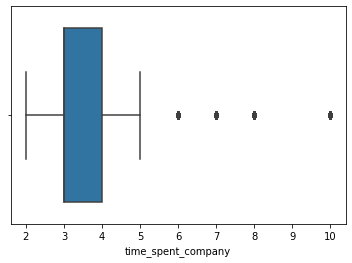

In [14]:
# Create a boxplot to visualize distribution of `time_spent_company` and detect any outliers
sns.boxplot(data=df1, x='time_spent_company')
plt.show()

In [15]:
# Remove outliers
df2 = df1.drop(outliers.index)

The outlier-free dataframe `df2` is retained for comparison. Because the predictive models used later are tree-based and comparatively robust to outliers, the modeling stage uses `df1`, which preserves these observations.


## Exploratory data analysis

The initial analysis examines relationships between employee characteristics and the target variable, with particular attention to satisfaction, performance evaluation, workload, tenure, workplace accidents, promotions, department, and salary.

The dataset contains nonlinear patterns that make tree-based classification models attractive. Duplicate observations are removed, column names are standardized, and an outlier-free copy is created for comparison while preserving the full cleaned dataset for tree-based modeling.


In [16]:
# Get numbers of people who left vs. stayed
print(df1.value_counts("left"))
# Get percentages of people who left vs. stayed
print(df1.value_counts("left", normalize=True))

left
0    10000
1     1991
dtype: int64
left
0    0.833959
1    0.166041
dtype: float64


Approximately 17% of employees in the cleaned dataset left the company. The target is therefore imbalanced, although the minority class remains large enough to support model training and evaluation without applying resampling in this analysis.


### Turnover patterns

The following visualizations compare employees who left with those who stayed. The goal is to identify potentially useful predictive relationships and generate business hypotheses before modeling.


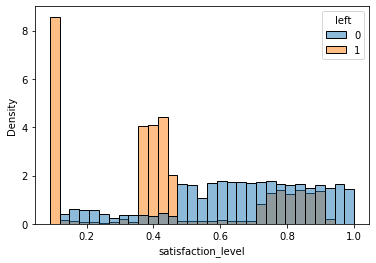

In [17]:
# Create a histogram of satisfaction level for employees who left and for those who stayed
sns.histplot(
    data=df1,
    x='satisfaction_level',
    hue='left',
    multiple='layer',
    stat='density',
    common_norm=False
)
plt.show()

Lower satisfaction levels are strongly associated with turnover. There is also a visible cluster of departing employees at higher satisfaction values, suggesting that the relationship is not simply linear.


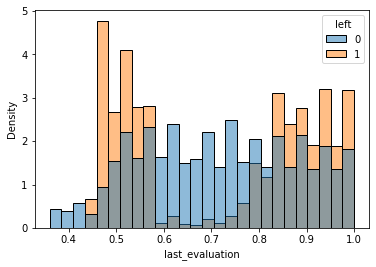

In [18]:
# Create a histogram of last evaluation for employees who left and for those who stayed
sns.histplot(
    data=df1,
    x='last_evaluation',
    hue='left',
    multiple='layer',
    stat='density',
    common_norm=False
)
plt.show()

Employees who stayed are concentrated more heavily in the middle of the evaluation range, while employees who left appear more frequently at both lower and higher evaluation scores. This suggests a nonlinear relationship between performance evaluation and turnover.


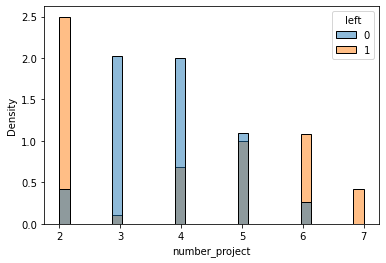

In [19]:
# Create a histogram of number of projects for employees who left and for those who stayed
sns.histplot(
    data=df1,
    x='number_project',
    hue='left',
    multiple='layer',
    stat='density',
    common_norm=False
)
plt.show()

Turnover also varies nonlinearly with project load: employees who left are more represented at both low and high numbers of projects.


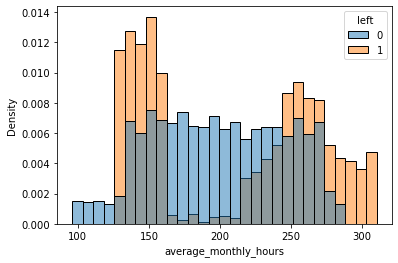

In [20]:
# Create a histogram of average monthly hours for employees who left and for those who stayed
sns.histplot(
    data=df1,
    x='average_monthly_hours',
    hue='left',
    multiple='layer',
    stat='density',
    common_norm=False
)
plt.show()

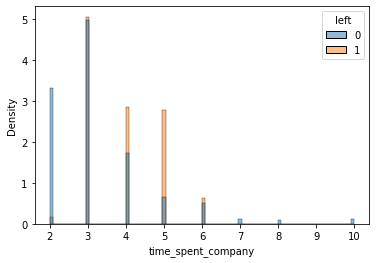

In [21]:
# Create a histogram of time spent in company for employees who left and for those who stayed
sns.histplot(
    data=df1,
    x='time_spent_company',
    hue='left',
    multiple='layer',
    stat='density',
    common_norm=False
)
plt.show()

Turnover is concentrated among employees with roughly 3–6 years of tenure, while both newer employees and those with longer tenure are more strongly represented among employees who stayed.


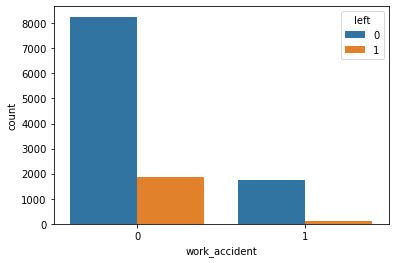

In [22]:
# Create a bar plot of workplace accidents for employees who left and for those who stayed
sns.countplot(
    data=df1,
    x='work_accident',
    hue='left'
)

plt.show()

Employees with recorded workplace accidents were disproportionately represented among those who stayed. The dataset establishes an association but does not provide enough information to determine why this pattern occurs.


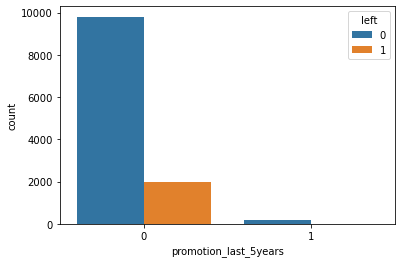

In [23]:
# Create a bar plot of promotions in the last 5 years for employees who left and for those who stayed
sns.countplot(
    data=df1,
    x='promotion_last_5years',
    hue='left'
)

plt.show()

Promotions were rare in the dataset, and promoted employees were overwhelmingly represented among those who stayed. Because promotions are uncommon, this pattern should be interpreted cautiously.


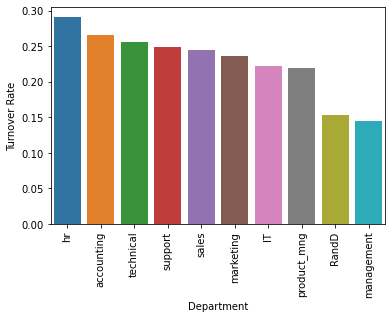

In [24]:
# Create a bar chart for the turnover rate in each department
turnover_by_dept = (
    df.groupby('department')['left']
      .mean()
      .sort_values(ascending=False)
)

sns.barplot(
    x=turnover_by_dept.index,
    y=turnover_by_dept.values
)

plt.xticks(rotation=90)
plt.ylabel('Turnover Rate')
plt.xlabel('Department')
plt.show()

Turnover rates are highest in HR, Accounting, Technical, Support, and Sales. The next analysis examines whether salary level helps explain differences across departments.


<Figure size 1008x432 with 0 Axes>

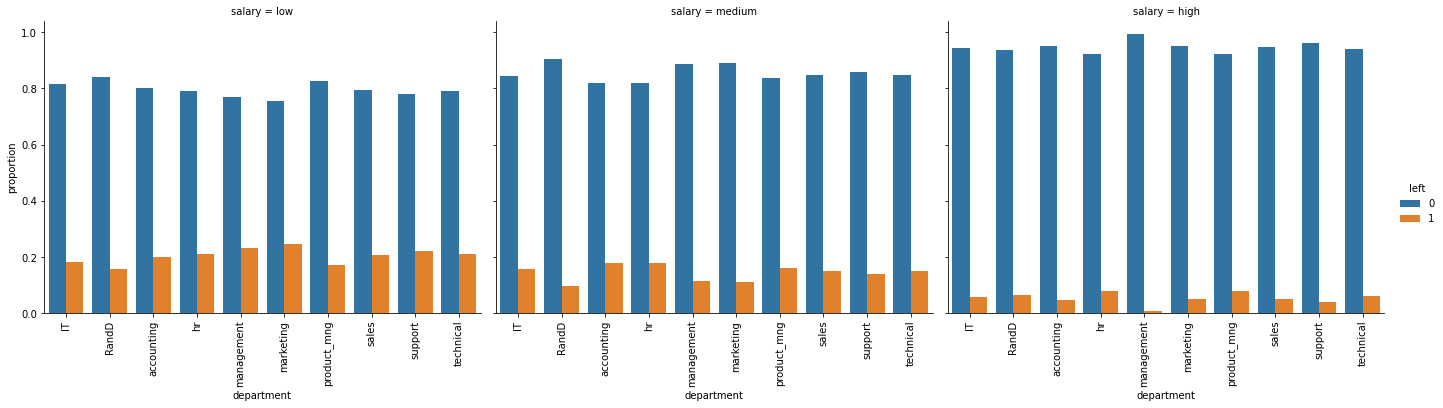

In [25]:
# Create a categorical plot for proportion of employees who left, separated by department and salary
plt.figure(figsize=(14, 6))

turnover_comparison = (
    df1.groupby(['department', 'salary'])['left']
       .value_counts(normalize=True)
       .rename('proportion')
       .reset_index()
)

g = sns.catplot(
    data=turnover_comparison,
    x='department',
    y='proportion',
    hue='left',
    col='salary',
    col_order=['low', 'medium', 'high'],
    kind='bar',
    height=5,
    aspect=1.3
)

g.set_xticklabels(rotation=90)
plt.show()

Salary level is associated with turnover across departments, with particularly visible differences in Management and IT. The analysis below also compares summary statistics between employees who stayed and those who left.


In [26]:
# Create a table comparing mean and median values for numerical columns
df.groupby('left')[[
    'satisfaction_level',
    'last_evaluation',
    'number_project',
    'average_monthly_hours',
    'time_spent_company'
]].agg(['mean', 'median'])

satisfaction_level        last_evaluation        number_project         \
                   mean median            mean median           mean median   
left                                                                          
0              0.666810   0.69        0.715473   0.71       3.786664    4.0   
1              0.440098   0.41        0.718113   0.79       3.855503    4.0   

     average_monthly_hours        time_spent_company         
                      mean median               mean median  
left                                                         
0               199.060203  198.0           3.380032    3.0  
1               207.419210  224.0           3.876505    4.0

### Key EDA findings


- Lower employee satisfaction is strongly associated with turnover.
- Performance evaluation shows a nonlinear relationship with turnover: employees in the middle of the range are more strongly represented among those who stayed, while departures appear more frequently toward both ends.
- Project count and monthly hours show similar nonlinear patterns, with turnover associated with unusually low or high workloads.
- Employees who left are concentrated in the 3–6 year tenure range.
- Employees with recorded workplace accidents were disproportionately represented among those who stayed; the available data do not establish a causal explanation.
- Promotions were uncommon, but promoted employees were overwhelmingly represented among those who stayed.
- Turnover was highest in HR, Accounting, Technical, Support, and Sales, and lowest in R&D and Management.
- Salary was associated with turnover, although later feature-importance results suggest that workload, satisfaction, and evaluation variables provide stronger predictive signals in the final model.


## Modeling strategy

All available predictor variables are retained. Because the EDA reveals nonlinear relationships, I compare two tree-based classifiers: **Random Forest** and **XGBoost**. These models can capture nonlinearities and interactions without the linearity assumptions required by logistic regression.

Categorical variables are one-hot encoded. The data are divided into training, validation, and test sets using stratification to preserve the turnover rate. Hyperparameters are tuned with `GridSearchCV`, using **recall** as the refit metric because failing to identify an employee who ultimately leaves is treated as more costly than incorrectly flagging an employee who stays.


### Prediction task

This is a **binary classification** problem: predict whether an employee leaves (`left = 1`) or stays (`left = 0`).


### Model selection

Random Forest and XGBoost were selected because they naturally capture the nonlinear relationships observed during EDA. Logistic regression would be a useful benchmark for future work, but it was not included in this version of the analysis.


In [27]:
# Apply one-hot encoding to the categorical variables "department" and "salary"
df_encoded = pd.get_dummies(
    df1,
    columns=['department', 'salary'],
    drop_first=False,
    dtype=int
)
df_encoded

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spent_company,work_accident,left,promotion_last_5years,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical,salary_high,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0
1,0.80,0.86,5,262,6,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1
2,0.11,0.88,7,272,4,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1
3,0.72,0.87,5,223,5,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0
4,0.37,0.52,2,159,3,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,0.90,0.55,3,259,10,1,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0
11996,0.74,0.95,5,266,10,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0
11997,0.85,0.54,3,185,10,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0
11998,0.33,0.65,3,172,10,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0


Tree-based models are well suited to the nonlinear relationships observed in the EDA and do not require eliminating correlated predictors solely to satisfy a linear-model assumption. The analysis therefore proceeds with the full encoded predictor set.


In [28]:
# Isolate variables and split into train, test, and validation sets
X = df_encoded.drop(columns=["left"])
y = df_encoded["left"]
X_tr, X_test, y_tr, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_tr, y_tr, stratify=y_tr, test_size=0.25, random_state=42)

In [33]:
# Use GridSearchCV to tune the random forest model
rf = RandomForestClassifier(random_state=42)
cv_params = {'max_depth': [10,20,30],
             'max_features': ["sqrt", 1.0],
             'max_samples': [0.5,1],
             'min_samples_leaf': [2,3],
             'min_samples_split': [2,3],
             'n_estimators': [100, 300],
             }
scoring = ['accuracy', 'precision', 'recall', 'f1']
rf_cv = GridSearchCV(rf, cv_params, scoring=scoring, cv=5, refit='recall')

In [34]:
# Fit the model
rf_cv.fit(X_train, y_train)

GridSearchCV(cv=5, error_score=nan,
             estimator=RandomForestClassifier(bootstrap=True, ccp_alpha=0.0,
                                              class_weight=None,
                                              criterion='gini', max_depth=None,
                                              max_features='auto',
                                              max_leaf_nodes=None,
                                              max_samples=None,
                                              min_impurity_decrease=0.0,
                                              min_impurity_split=None,
                                              min_samples_leaf=1,
                                              min_samples_split=2,
                                              min_weight_fraction_leaf=0.0,
                                              n_estimators=100, n_jobs=None,
                                              oob_score=False, random_state=42,
                                  

In [35]:
# Identify best score and best hyperparameter combo
print(rf_cv.best_score_)
print(rf_cv.best_params_)

0.9046025104602512
{'max_depth': 10, 'max_features': 1.0, 'max_samples': 0.5, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 300}


In [36]:
#Define a function to output model scores during cross-validation on the training data
def make_results(model_name:str, model_object, metric:str):
    metric_dict = {'precision': 'mean_test_precision',
                   'recall': 'mean_test_recall',
                   'f1': 'mean_test_f1',
                   'accuracy': 'mean_test_accuracy',
                   }
    cv_results = pd.DataFrame(model_object.cv_results_)
    best_estimator_results = cv_results.iloc[cv_results[metric_dict[metric]].idxmax(), :]
    f1 = best_estimator_results.mean_test_f1
    recall = best_estimator_results.mean_test_recall
    precision = best_estimator_results.mean_test_precision
    accuracy = best_estimator_results.mean_test_accuracy
    table = pd.DataFrame({'model': [model_name],
                          'precision': [precision],
                          'recall': [recall],
                          'F1': [f1],
                          'accuracy': [accuracy],
                          },
                         )
    return table

In [37]:
# Create table with best model scores
results = make_results('RF cv', rf_cv, 'recall')
results

,model,precision,recall,F1,accuracy
0,RF cv,0.970652,0.904603,0.936164,0.979566


### XGBoost

An XGBoost classifier is tuned next to determine whether boosting can improve recall while maintaining strong precision and overall performance.


In [45]:
# Use GridSearchCV to tune the XGBoost model
xgb = XGBClassifier(objective="binary:logistic", random_state=42)
cv_params = {'max_depth': [3, 6],
             'min_child_weight': [3, 5],
             'learning_rate': [0.05, 0.1],
             'n_estimators': [100, 300]
            }
xgb_cv = GridSearchCV(
    xgb,
    cv_params,
    scoring=scoring,
    cv=4,
    refit='recall',
    n_jobs=-1,
    verbose=2
)

In [46]:
# Fit the model
xgb_cv.fit(X_train, y_train)

Fitting 4 folds for each of 16 candidates, totalling 64 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 out of  64 | elapsed:   53.0s remaining:   46.8s
[Parallel(n_jobs=-1)]: Done  64 out of  64 | elapsed:  1.1min finished


GridSearchCV(cv=4, error_score=nan,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     gamma=None, gpu_id=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None, max...
                                     num_parallel_tree=None,
                                     objective='binary:logistic',
                                     predictor=None, random_state=42,
                                     reg_alpha=None, ...),
             iid='deprecate

In [47]:
# Identify best score and best hyperparameter combo
print(xgb_cv.best_score_)
print(xgb_cv.best_params_)

0.9137954254674419
{'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 300}


In [48]:
# Create table with best model scores
xgb_cv_results = make_results('XGB cv', xgb_cv, 'recall')
results = pd.concat([results, xgb_cv_results], axis=0)
results

,model,precision,recall,F1,accuracy
0,RF cv,0.970652,0.904603,0.936164,0.979566
0,XGB cv,0.959841,0.913795,0.936009,0.979288


### Validation and champion-model selection

Both tuned models are evaluated on the validation set. The validation results are used to select the champion model before evaluating it once on the held-out test set.


In [49]:
#Define a function to output model scores on unseen data
def get_test_scores(model_name:str, preds, y_test_data):
    accuracy = accuracy_score(y_test_data, preds)
    precision = precision_score(y_test_data, preds)
    recall = recall_score(y_test_data, preds)
    f1 = f1_score(y_test_data, preds)
    table = pd.DataFrame({'model': [model_name],
                          'precision': [precision],
                          'recall': [recall],
                          'F1': [f1],
                          'accuracy': [accuracy]
                          })
    return table

In [50]:
# Apply the validation data to the Random Forest model and output model scores
rf_val_preds = rf_cv.best_estimator_.predict(X_val)
rf_val_scores = get_test_scores('RF val', rf_val_preds, y_val)
results = pd.concat([results, rf_val_scores], axis=0)
results

,model,precision,recall,F1,accuracy
0,RF cv,0.970652,0.904603,0.936164,0.979566
0,XGB cv,0.959841,0.913795,0.936009,0.979288
0,RF val,0.970588,0.912060,0.940415,0.980817


In [51]:
# Apply the validation data to the XGB model and output model scores
xgb_val_preds = xgb_cv.best_estimator_.predict(X_val)
xgb_val_scores = get_test_scores('XGB val', xgb_val_preds, y_val)
results = pd.concat([results, xgb_val_scores], axis=0)
results

,model,precision,recall,F1,accuracy
0,RF cv,0.970652,0.904603,0.936164,0.979566
0,XGB cv,0.959841,0.913795,0.936009,0.979288
0,RF val,0.970588,0.912060,0.940415,0.980817
0,XGB val,0.963061,0.917085,0.939511,0.980400


Random Forest achieves slightly higher precision on the validation set, while XGBoost achieves higher recall; their F1 scores are nearly identical. Because the business objective prioritizes identifying employees who are likely to leave, **XGBoost is selected as the champion model based on recall**.


In [52]:
# Use XGBoost model to predict on test data
xgb_test_preds = xgb_cv.best_estimator_.predict(X_test)
xgb_test_scores = get_test_scores('XGB test', xgb_test_preds, y_test)
results = pd.concat([results, xgb_test_scores], axis=0)
results

,model,precision,recall,F1,accuracy
0,RF cv,0.970652,0.904603,0.936164,0.979566
0,XGB cv,0.959841,0.913795,0.936009,0.979288
0,RF val,0.970588,0.912060,0.940415,0.980817
0,XGB val,0.963061,0.917085,0.939511,0.980400
0,XGB test,0.953488,0.927136,0.940127,0.980409


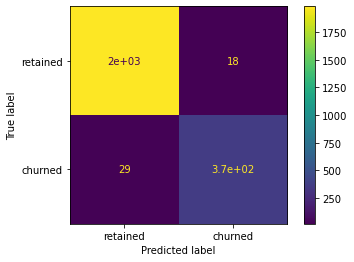

In [53]:
# Generate array of values for confusion matrix
### YOUR CODE HERE ###

cm = confusion_matrix(y_test, xgb_test_preds, labels=xgb_cv.classes_)

# Plot confusion matrix
### YOUR CODE HERE ###

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['retained', 'churned'])
disp.plot();

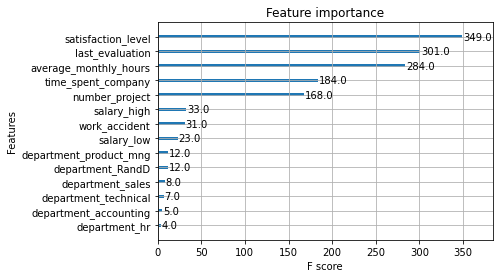

In [54]:
plot_importance(xgb_cv.best_estimator_);

## Results and recommendations

The champion XGBoost model achieved approximately **98.0% accuracy, 95.3% precision, 92.7% recall, and a 94.0% F1 score** on the held-out test set. The high recall means the model identified most employees in the test set who actually left.

Feature importance indicates that satisfaction level, evaluation results, and workload-related variables are among the strongest predictive signals. Salary is associated with turnover in the exploratory analysis, but it is not among the foremost features in the final XGBoost importance ranking.

### Business recommendations

HR should prioritize monitoring broad patterns in employee satisfaction and unusually high or low workloads. Employees with extreme project loads or monthly hours, as well as employees in the 3–6 year tenure range, may warrant additional attention through supportive retention initiatives.

The analysis should not be interpreted causally. For example, the model can identify associations between workload and turnover but cannot establish that changing workload alone will prevent an employee from leaving. Follow-up surveys or qualitative research could help determine which interventions employees actually value.

### Limitations and next steps

A broader hyperparameter search could potentially improve performance. A logistic-regression baseline would provide an interpretable benchmark, while threshold tuning and additional model-explanation techniques could clarify the tradeoff between recall and precision.

Future analysis could investigate what drives unusually high or low workloads, which interventions improve satisfaction, whether the 3–6 year tenure pattern persists over time, and how retention strategies perform when evaluated prospectively.
